In [2]:
#Importing relevent packages
import sys; print(sys.executable)
import parcels
import math
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature
from datetime import datetime, timedelta

/nethome/6903894/parcels_env/bin/python


In [3]:
#TEMPERATURE LIMITATION
#Initializing temperature array in deg Celsius
T = np.arange(12,41,0.5)

#Model parameters based on Jouanno et al. (2021) in deg Celsius
T_opt_J = 26
Tmin_J = 10.5
Tmax_J = 43.8
Tx = np.full_like(T,Tmin_J)  #Tx describes lower limit or upper limit under/above which there is no growth
Tx[T > T_opt_J] = Tmax_J

#Model parameters based on Podlejski et al. (2024) in deg Celsius
T_opt_P = 27.5
Tmin_P = 24
Tmax_P = 28
Tref = np.full_like(T,Tmin_P)  #Tref describes lower limit or upper limit under/above which there is no growth
Tref[T > T_opt_P] = Tmax_P

#Model parameters based on Bonner et al. (2024) in deg Celsius
Tmin_B = 10
Tmax_B = 40
T_opt_B = (Tmin_B + Tmax_B) / 2 
Tx_B = np.full_like(T,Tmin_B)  #Tx describes lower limit or upper limit under/above which there is no growth
Tx_B[T > T_opt_B] = Tmax_B

#Model parameters based on Jouanno et al. (2025) in deg Celsius
Tmin_J25 = 20
Tmax_J25 = 31
T_opt_J25 = 27.5 
Tx25 = np.full_like(T,Tmin_J25)  #Tx describes lower limit or upper limit under/above which there is no growth
Tx25[T > T_opt_J25] = Tmax_J25

#Growth limitation dependent on temperature, formula from Jouanno et al. (2021) and (2025)
growth_limitation_T_J = np.exp(-0.5 * ( (T - T_opt_J)/ (Tx - T))**2 )
growth_limitation_T_J25 = np.exp(-2 * ( (T - T_opt_J25)/ (Tx25 - T_opt_J25))**2 )

#Growth limitation dependent on temperature, formula from Podlejski et al. (2024).
growth_limitation_T_P = np.exp(-2 * ((T - T_opt_P)/ (Tref - T))**2 )

#Growth limitation dependent on temperature, formula from Bonner et al. (2024).
growth_limitation_T_B = np.exp(-0.5 * ( (T - T_opt_B)/ (Tx - T))**2 )



#LIGHT LIMITATION
#Initializing incoming sunlight array in W/m2
I = np.arange(0,301,1)

#Optimal light intensity, from Jouanno et al. (2021), possible range from 60-80
I_opt_J = 62.3 #W/m2
I_opt_J25 = 180
#Optimal light intensity and minimum irradiance value, from Podlejski et al. (2024)
I_opt_P = 170 #W/m2
I_min_P = 30

#Growth limitation dependent on incoming irradiance, formula from Jouanno et al. (2021).
growth_limitation_I_J = 1 / ( 1 + np.exp(-0.1 * I / I_opt_J))
growth_limitation_I_J25 = 1 / ( 1 + np.exp(-0.1*0.41*(I-I_opt_J25)))

#Growth limitation dependent on incoming irriadiance, formula from Podlejski et al. (2024).
growth_limitation_I_P = ((I - I_min_P)/I_opt_P) * np.exp( 1 - ((I - I_min_P)/I_opt_P) )

/tmp/ipykernel_3707/513188673.py:38: RuntimeWarning: divide by zero encountered in divide
  growth_limitation_T_P = np.exp(-2 * ((T - T_opt_P)/ (Tref - T))**2 )


In [3]:
#Experimental data from Magaña-Gallegos et al. (2023)
#Relative Growth Rates - RGR [doubling day-1]
fluitans = [0.078, 0.077, 0.095, 0.058]
natansI = [0.057, 0.067, 0.063, 0.054]
natansVIII = [0.058, 0.059, 0.053, 0.045]

#Corresponding temperatures
temp_exp = [22, 25, 28, 31]

growth_limitation_T_nviii = np.max(natansVIII) * np.exp(-0.5 * ( (T - T_opt_J)/ (T - Tx_B))**2 )

/tmp/ipykernel_3889/886624579.py:10: RuntimeWarning: divide by zero encountered in divide
  growth_limitation_T_nviii = np.max(natansVIII) * np.exp(-0.5 * ( (T - T_opt_J)/ (T - Tx_B))**2 )


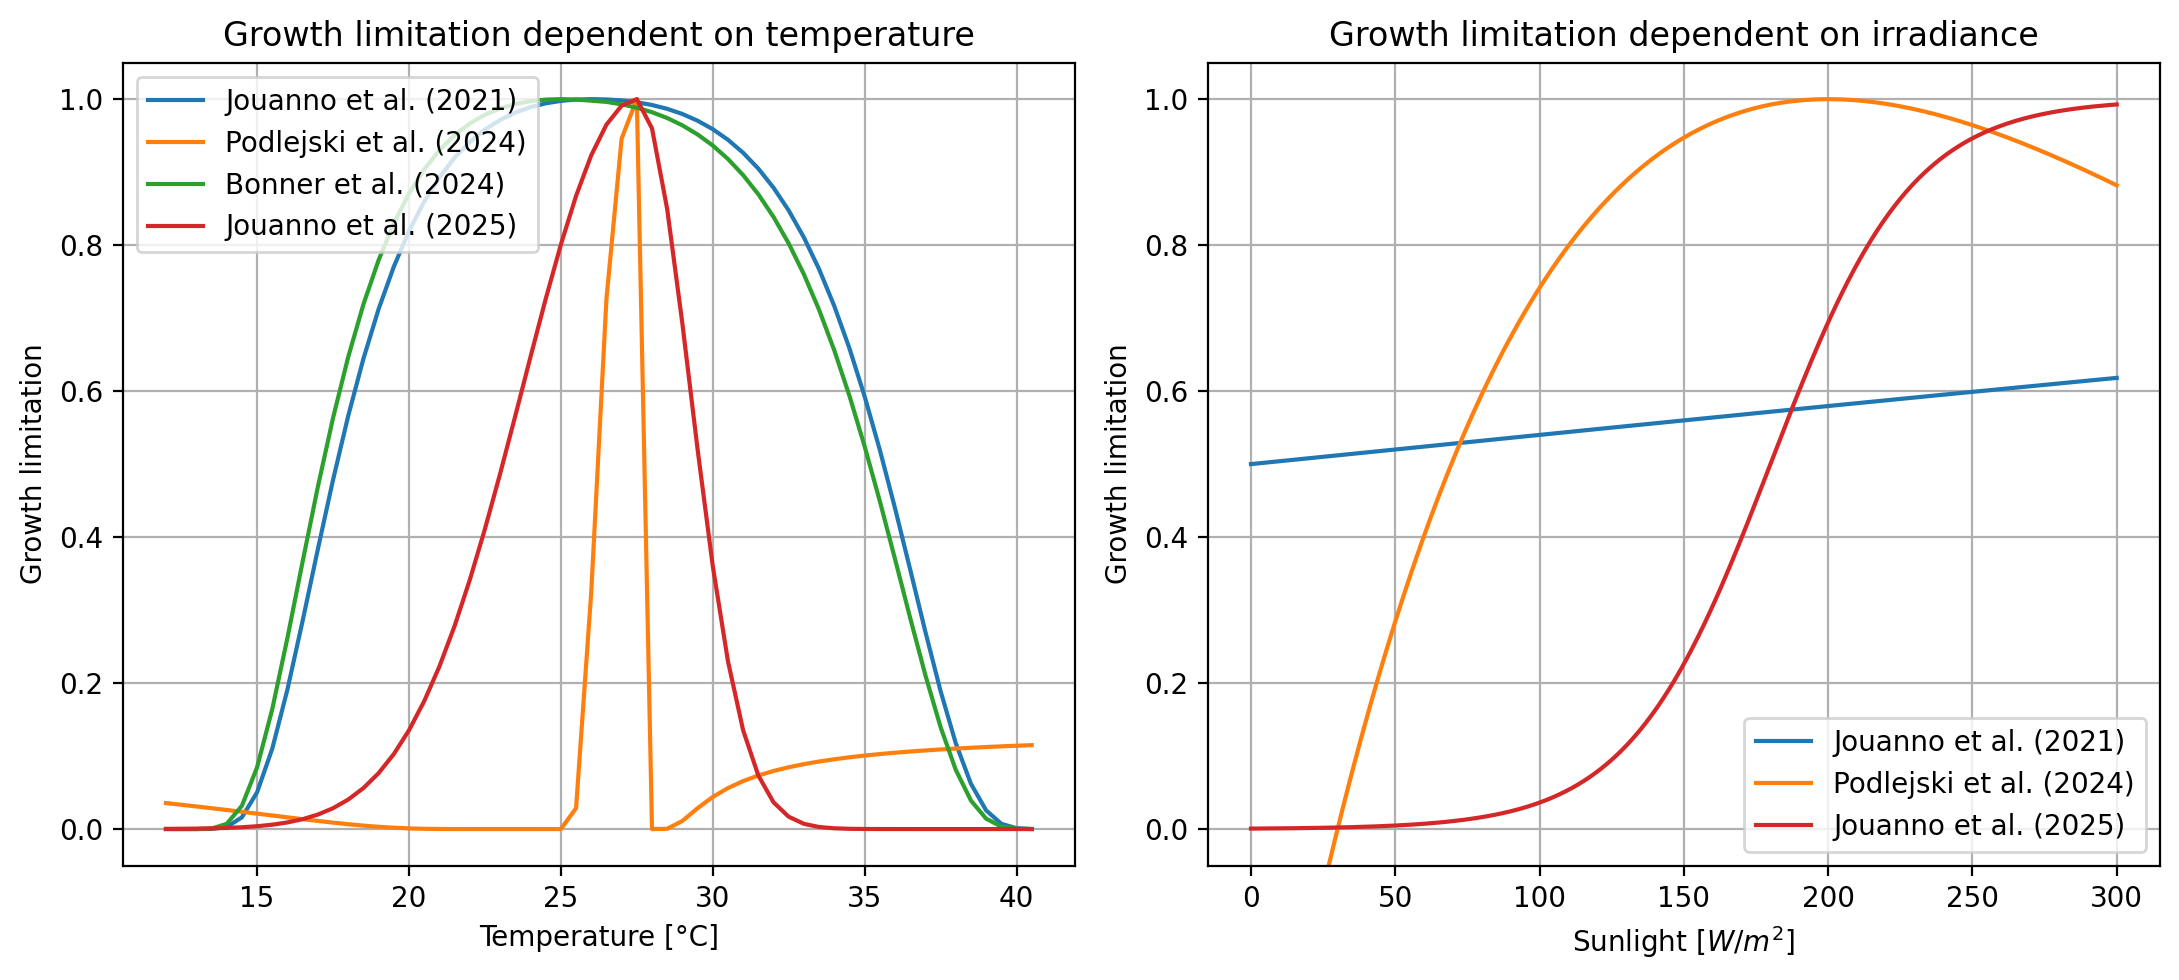

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), dpi = 200)

#Temperature
ax1.plot(T, growth_limitation_T_J, label='Jouanno et al. (2021)')
ax1.plot(T, growth_limitation_T_P, label='Podlejski et al. (2024)')
ax1.plot(T, growth_limitation_T_B, label='Bonner et al. (2024)')
ax1.plot(T, growth_limitation_T_J25, label='Jouanno et al. (2025)')
ax1.set_xlabel('Temperature [°C]')
ax1.set_ylabel('Growth limitation')
ax1.set_title('Growth limitation dependent on temperature')
ax1.grid()
ax1.legend(loc='upper left')

#Sunlight
ax2.plot(I, growth_limitation_I_J, label = 'Jouanno et al. (2021)')
ax2.plot(I, growth_limitation_I_P, label = 'Podlejski et al. (2024)')
ax2.plot(I, growth_limitation_I_J25, label = 'Jouanno et al. (2025)', c = 'tab:red')
ax2.set_xlabel('Sunlight [$W/m^2$]')
ax2.set_ylabel('Growth limitation')
ax2.set_title('Growth limitation dependent on irradiance')
ax2.legend()
ax2.set_ylim(-0.05,1.05)
ax2.grid()

plt.tight_layout()
plt.show()

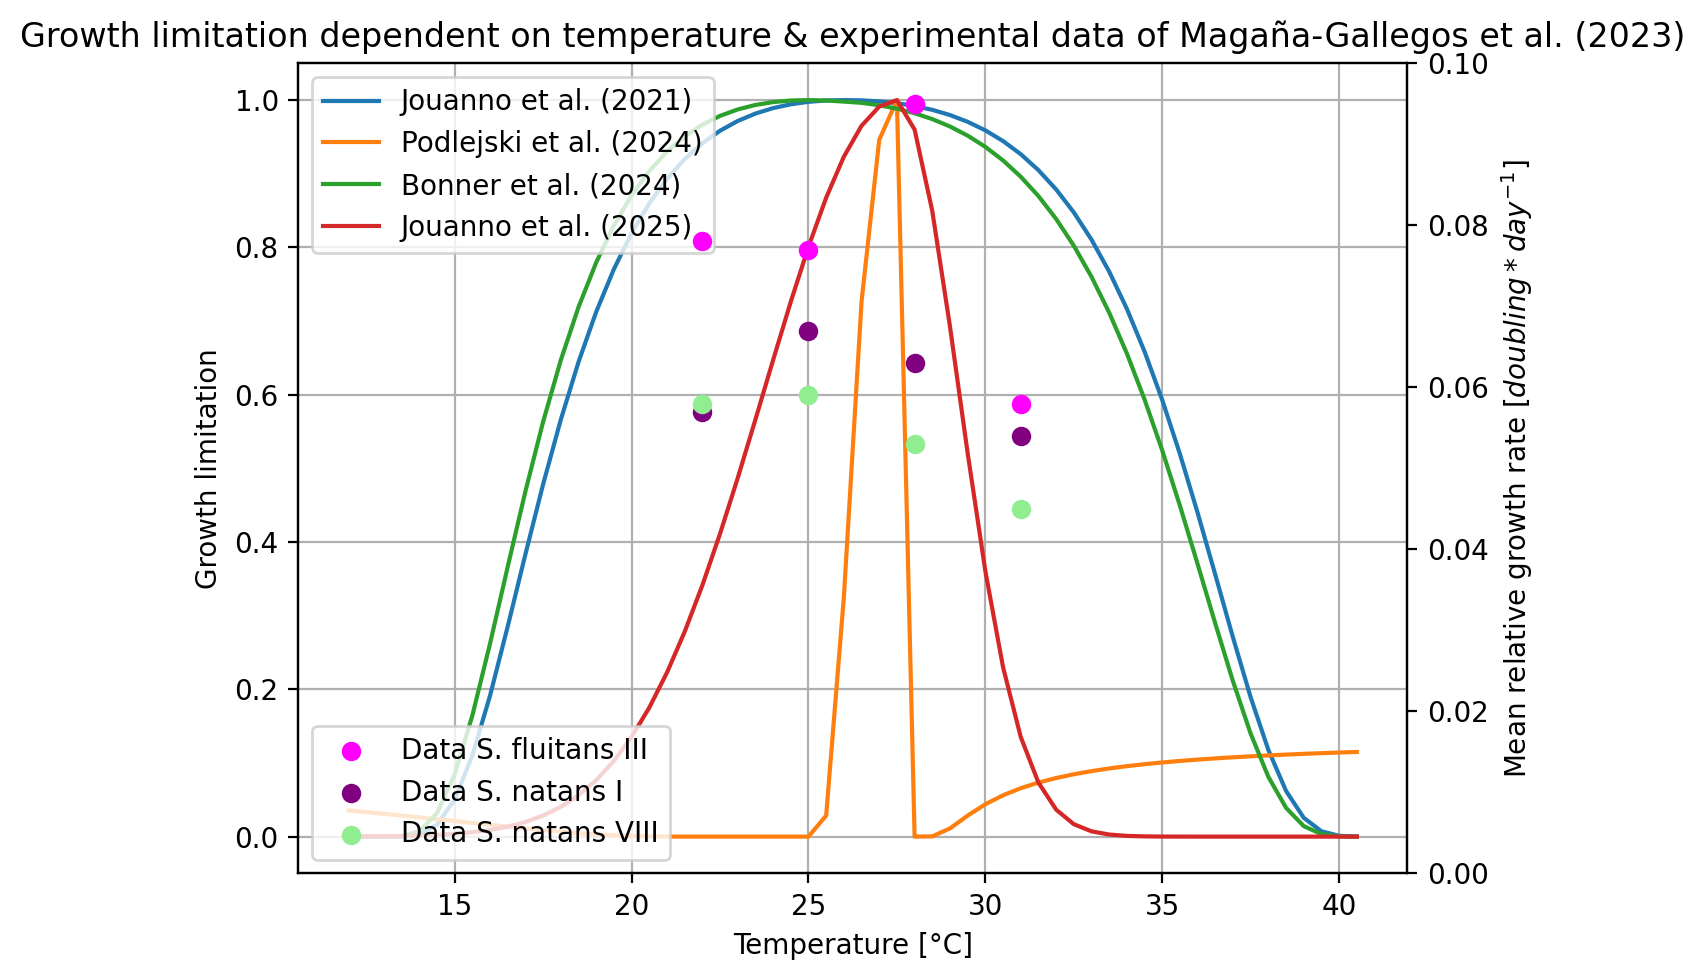

In [5]:
fig, (ax1) = plt.subplots(1, 1, figsize=(7, 5), dpi = 200)

#Temperature
ax1.plot(T, growth_limitation_T_J, label='Jouanno et al. (2021)')
ax1.plot(T, growth_limitation_T_P, label='Podlejski et al. (2024)')
ax1.plot(T, growth_limitation_T_B, label='Bonner et al. (2024)')
ax1.plot(T, growth_limitation_T_J25, label='Jouanno et al. (2025)')
ax1.set_xlabel('Temperature [°C]')
ax1.set_ylabel('Growth limitation')
ax1.set_title('Growth limitation dependent on temperature & experimental data of Magaña-Gallegos et al. (2023)')
ax1.grid()

# Temperature - Secondary axis for experimental data
ax1b = ax1.twinx()
#ax1b.plot(T,growth_limitation_T_nviii, color='lightblue')
ax1b.scatter(temp_exp, fluitans, color='magenta', label='Data S. fluitans III', zorder=5)
ax1b.scatter(temp_exp, natansI, color='purple', label='Data S. natans I', zorder=5)
ax1b.scatter(temp_exp, natansVIII, color='lightgreen', label='Data S. natans VIII', zorder=5)
ax1b.set_ylabel('Mean relative growth rate [$doubling * day^{-1}$]')
# Optional: Match y limits if needed
ax1b.set_ylim(0,0.1)

ax1.legend(loc='upper left')
ax1b.legend(loc='lower left')

plt.tight_layout()
plt.show()

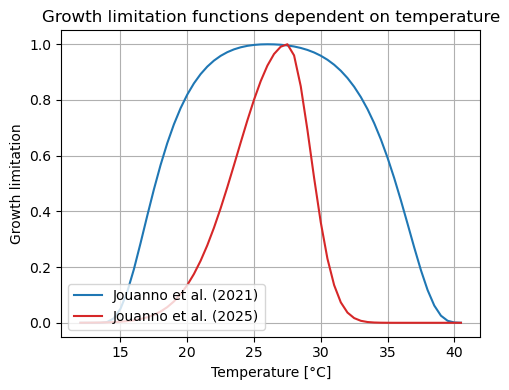

In [7]:
fig, (ax1) = plt.subplots(1, 1, figsize=(5, 4))

#Temperature
ax1.plot(T, growth_limitation_T_J, label='Jouanno et al. (2021)')
#ax1.plot(T, growth_limitation_T_P, label='Podlejski et al. (2024)')
#ax1.plot(T, growth_limitation_T_B, label='Bonner et al. (2024)')
ax1.plot(T, growth_limitation_T_J25, label='Jouanno et al. (2025)', c = 'tab:red')
ax1.set_xlabel('Temperature [°C]')
ax1.set_ylabel('Growth limitation')
ax1.set_title('Growth limitation functions dependent on temperature')
ax1.grid()

ax1.legend(loc='lower left')

plt.tight_layout()
plt.show()

In [5]:
#NUTRIETN LIMITATION
#Initializing nitrogen array in ....
Q_N = np.arange(0.024,0.085,0.0005)

N_conc = np.arange(0,1,0.00002)

print(Q_N)

#Model parameters based on Jouanno et al. (2021) in mg N / mg C
Q_N_min = 0.027
Q_N_max = 0.034
#Model parameters based on Jouanno et al. (2025) in mg N / mg C
Q_N_min_25 = 0.05
Q_N_max_25 = 0.08

#Sargassum nitrogen uptake half saturation according to Bonner et al
k_n_B  = 0.000129 #mmol/ m3

growth_limitation_nitrogen_B = 1 / (1+ k_n_B / N_conc)

#Growth limitation dependent on nitrogen availability, formula from Jouanno et al. (2021).
growth_limitation_nitrogen_J21 = ( ( 1- Q_N_min / Q_N ) / ( 1 - Q_N_min / Q_N_max) )

#Growth limitation dependent on nitrogen availability, formula from Jouanno et al. (2021).
growth_limitation_nitrogen_J25 = ( ( 1- Q_N_min_25 / Q_N ) / ( 1 - Q_N_min_25 / Q_N_max_25) )


#SALINITY LIMITATION
#Initializing salinity array in 
S_ = np.arange(31,38,0.05)
#Growth limitation dependent on nitrogen availability, formula from Jouanno et al. (2025).
growth_limitation_salinityJ = np.exp(-0.02 * (36-S_)**2)
growth_limitation_salinityP = 0.0714 * S_ - 1.5714

#CARBON CONTENT LIMITATION (SARGASSUM DENSITY LIMITATION)
C_conc = np.arange(0.000001,0.0001, 0.0000001)
K_c = 0.0002 #mg C / m2
#Growth limitation dependent on carbon content, formula from Jouanno et al. (2025)
growth_limitation_C_J25 = 1 - (C_conc / (K_c + C_conc))

[0.024  0.0245 0.025  0.0255 0.026  0.0265 0.027  0.0275 0.028  0.0285
 0.029  0.0295 0.03   0.0305 0.031  0.0315 0.032  0.0325 0.033  0.0335
 0.034  0.0345 0.035  0.0355 0.036  0.0365 0.037  0.0375 0.038  0.0385
 0.039  0.0395 0.04   0.0405 0.041  0.0415 0.042  0.0425 0.043  0.0435
 0.044  0.0445 0.045  0.0455 0.046  0.0465 0.047  0.0475 0.048  0.0485
 0.049  0.0495 0.05   0.0505 0.051  0.0515 0.052  0.0525 0.053  0.0535
 0.054  0.0545 0.055  0.0555 0.056  0.0565 0.057  0.0575 0.058  0.0585
 0.059  0.0595 0.06   0.0605 0.061  0.0615 0.062  0.0625 0.063  0.0635
 0.064  0.0645 0.065  0.0655 0.066  0.0665 0.067  0.0675 0.068  0.0685
 0.069  0.0695 0.07   0.0705 0.071  0.0715 0.072  0.0725 0.073  0.0735
 0.074  0.0745 0.075  0.0755 0.076  0.0765 0.077  0.0775 0.078  0.0785
 0.079  0.0795 0.08   0.0805 0.081  0.0815 0.082  0.0825 0.083  0.0835
 0.084  0.0845 0.085 ]


/tmp/ipykernel_3707/1321937423.py:19: RuntimeWarning: divide by zero encountered in divide
  growth_limitation_nitrogen_B = 1 / (1+ k_n_B / N_conc)


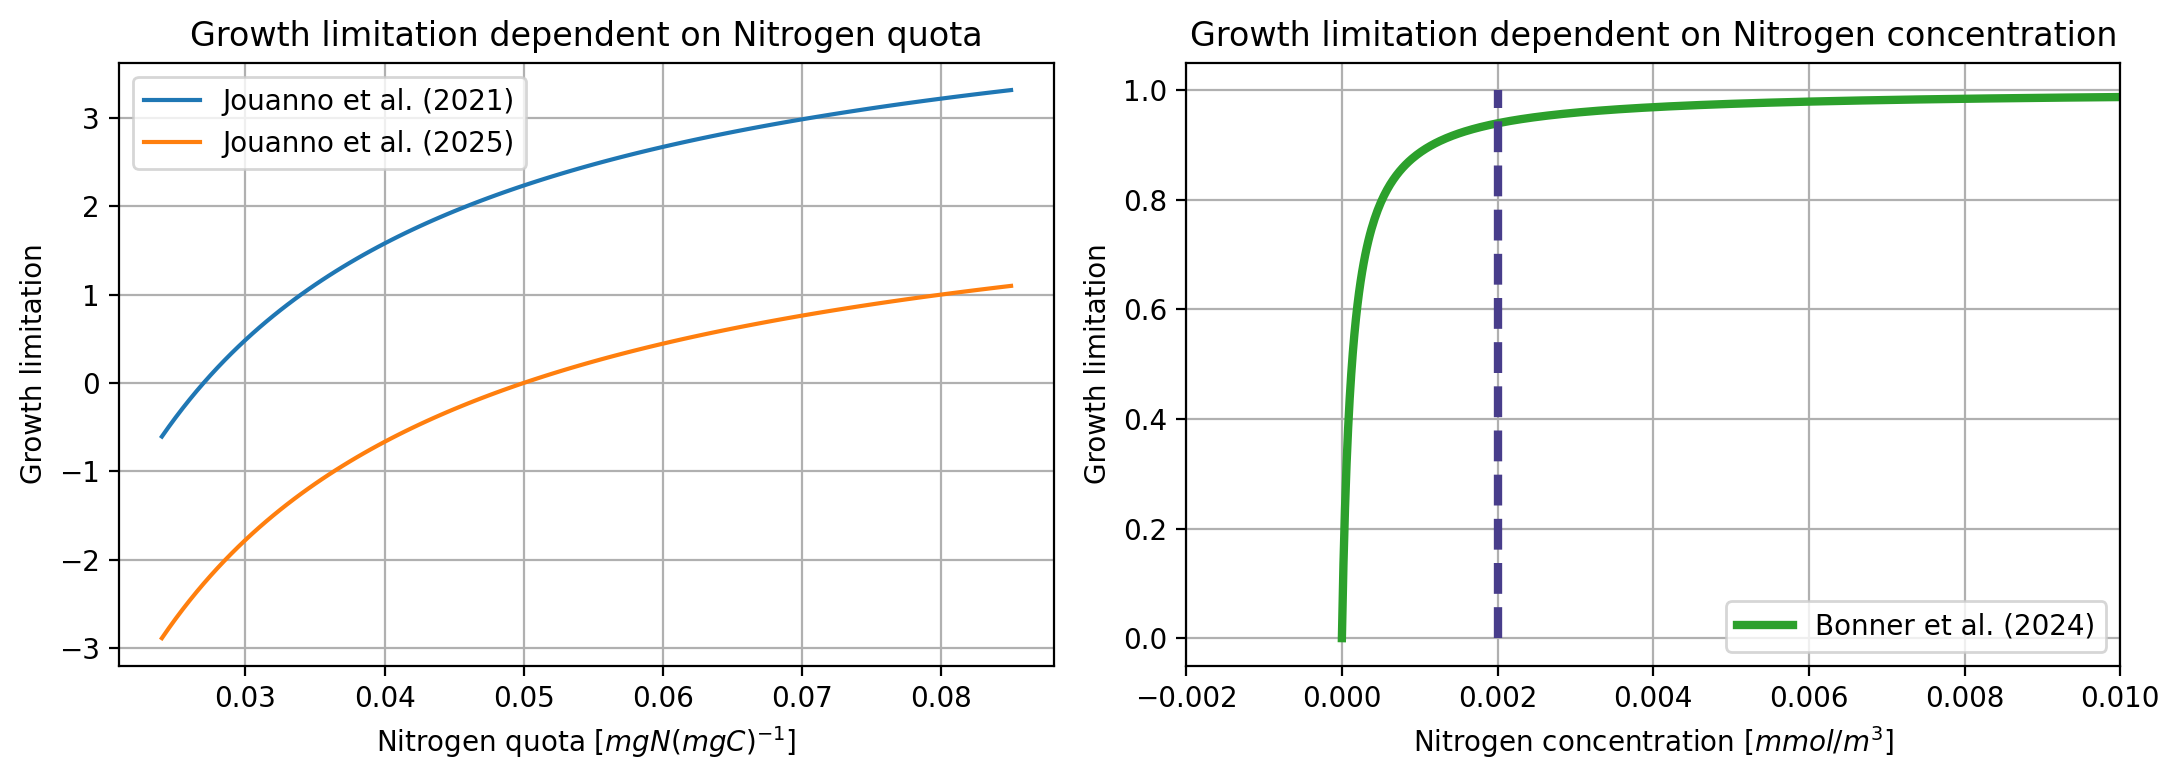

In [14]:
fignutrients, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), dpi = 200)

#Nitrogen quota
ax1.plot(Q_N, growth_limitation_nitrogen_J21, label='Jouanno et al. (2021)')
ax1.plot(Q_N, growth_limitation_nitrogen_J25, label='Jouanno et al. (2025)')
#ax1.plot(T, growth_limitation_T_P, label='Podlejski et al. (2024)')
ax1.set_xlabel('Nitrogen quota [$mg N (mg C)^{-1}$]')
ax1.set_ylabel('Growth limitation')
ax1.set_title('Growth limitation dependent on Nitrogen quota')
ax1.grid()
ax1.legend(loc='upper left')

#Nitrogen concentration
ax2.plot(N_conc, growth_limitation_nitrogen_B, label = 'Bonner et al. (2024)', linewidth = 3, color='tab:green')
ax2.set_xlabel('Nitrogen concentration [$mmol / m^3$]')
ax2.set_ylabel('Growth limitation')
ax2.set_title('Growth limitation dependent on Nitrogen concentration')
ax2.legend()
ax2.set_xlim(-0.002,0.01)
ax2.vlines(0.002, 0,1, linestyles='dashed', linewidth = 3,  color='darkslateblue')
ax2.grid()

plt.tight_layout()
plt.show()

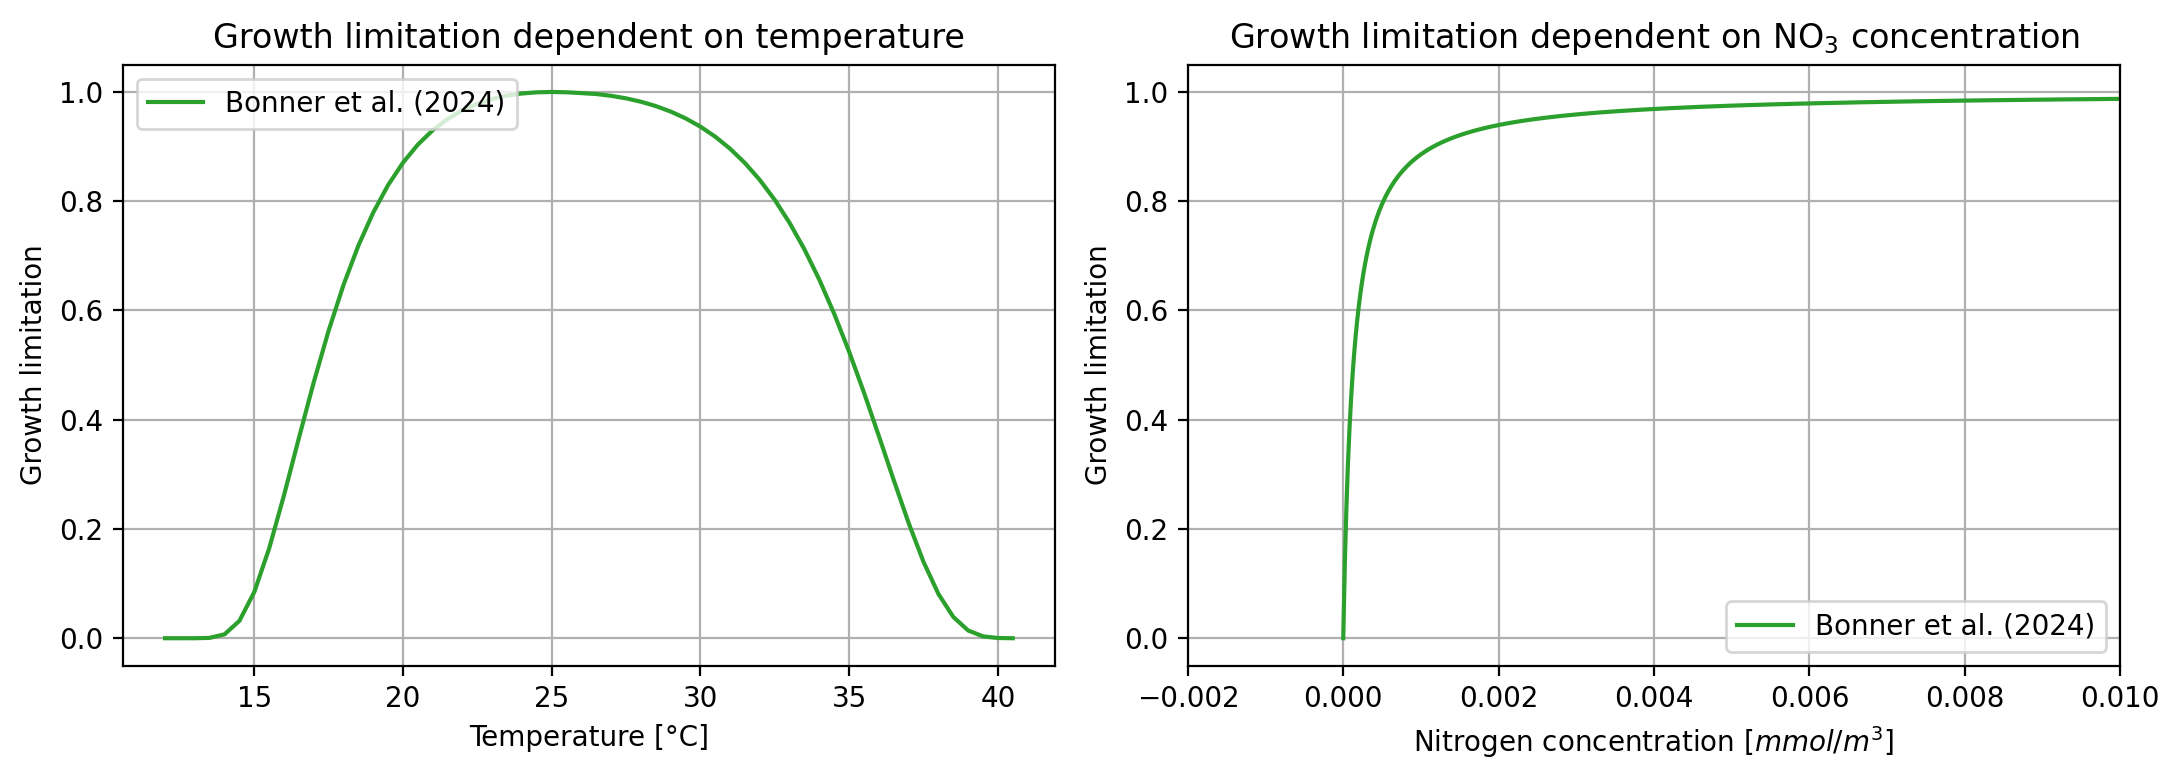

In [10]:
fignutrients, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), dpi = 200)

#Temperature
ax1.plot(T, growth_limitation_T_B, label='Bonner et al. (2024)', color='tab:green')
ax1.set_xlabel('Temperature [°C]')
ax1.set_ylabel('Growth limitation')
ax1.set_title('Growth limitation dependent on temperature')
ax1.grid()
ax1.legend(loc='upper left')

#Nitrogen concentration
ax2.plot(N_conc, growth_limitation_nitrogen_B, label = 'Bonner et al. (2024)', color='tab:green')
ax2.set_xlabel('Nitrogen concentration [$mmol / m^3$]')
ax2.set_ylabel('Growth limitation')
ax2.set_title(f'Growth limitation dependent on NO$_3$ concentration')
ax2.legend()
ax2.set_xlim(-0.002,0.01)
#ax2.vlines(0.002, 0,1, linestyles='dashed', color='darkslateblue')
ax2.grid()

plt.tight_layout()
plt.show()

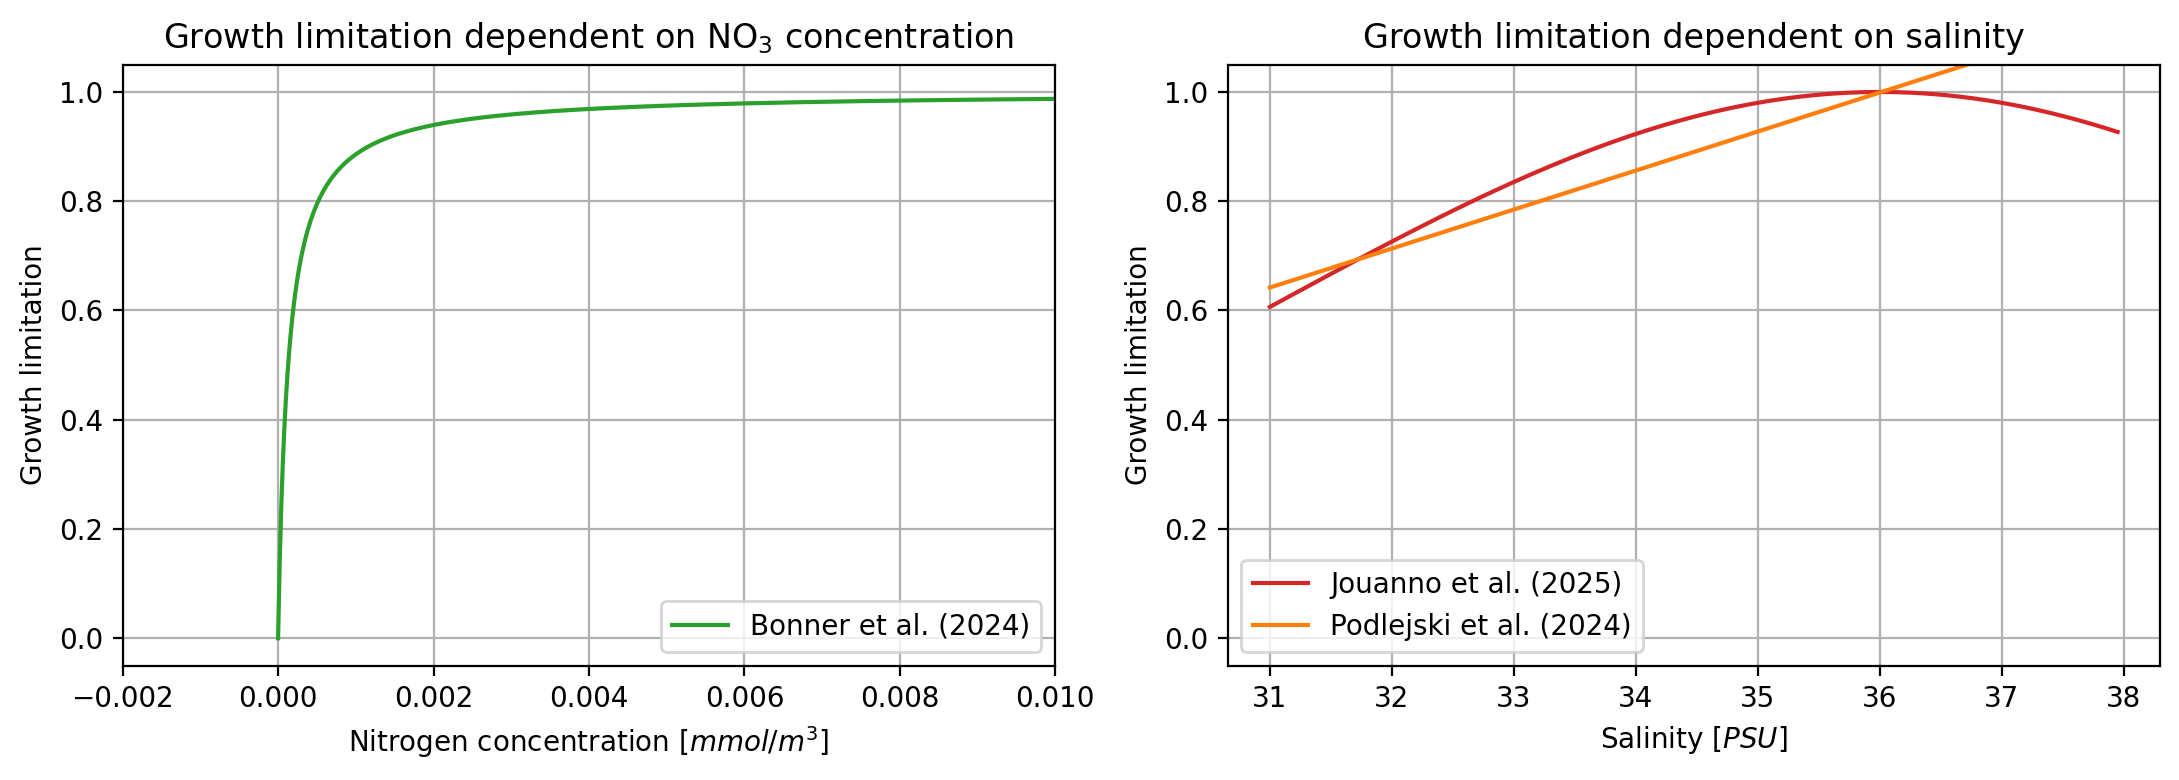

In [7]:
figlim3, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), dpi = 200)

#Nitrogen concentration
ax1.plot(N_conc, growth_limitation_nitrogen_B, label = 'Bonner et al. (2024)', color='tab:green')
ax1.set_xlabel('Nitrogen concentration [$mmol / m^3$]')
ax1.set_ylabel('Growth limitation')
ax1.set_title(f'Growth limitation dependent on NO$_3$ concentration')
ax1.legend()
ax1.set_xlim(-0.002,0.01)
ax1.grid()

#Salinity
ax2.plot(S_, growth_limitation_salinityJ, label = 'Jouanno et al. (2025)', color='tab:red')
ax2.plot(S_, growth_limitation_salinityP, label = 'Podlejski et al. (2024)', color= 'tab:orange')
ax2.set_xlabel('Salinity [$PSU$]')
ax2.set_ylabel('Growth limitation')
ax2.set_title('Growth limitation dependent on salinity')
ax2.legend()
ax2.set_ylim(-0.05,1.05)
ax2.grid()

plt.tight_layout()
plt.show()

NameError: name 'C_conc' is not defined

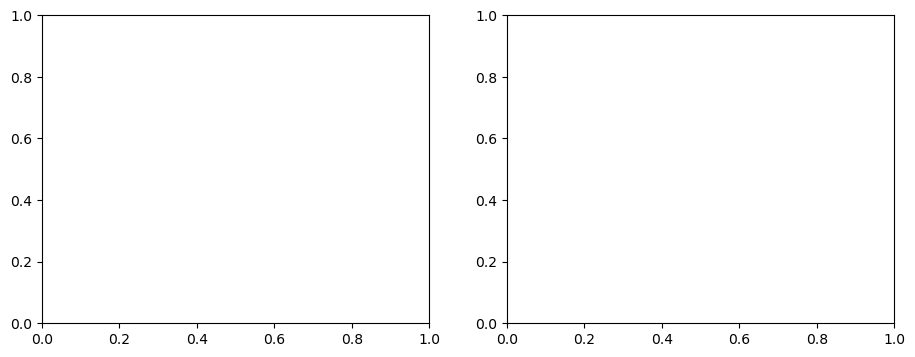

In [4]:
figlim3, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

#Temperature
#ax1.plot(Q_N, growth_limitation_nitrogen_J21, label='Jouanno et al. (2021)')
ax1.plot(C_conc, growth_limitation_C_J25, label='Jouanno et al. (2025)')
#ax1.plot(T, growth_limitation_T_P, label='Podlejski et al. (2024)')
ax1.set_xlabel('Carbon concentration [$mg C / m^{2}$]')
ax1.set_ylabel('Growth limitation')
ax1.set_title('Growth limitation dependent on Nitrogen quota')
ax1.grid()
ax1.legend(loc='upper left')

#Sunlight
ax2.plot(S_, growth_limitation_salinityJ, label = 'Jouanno et al. (2025)')
ax2.plot(S_, growth_limitation_salinityP, label = 'Podlejski et al. (2024)')
ax2.set_xlabel('Salinity [$PSU$]')
ax2.set_ylabel('Growth limitation')
ax2.set_title('Growth limitation dependent on salinity')
ax2.legend()
ax2.set_ylim(-0.05,1.05)
ax2.grid()

plt.tight_layout()
plt.show()